# Prédiction d'espèces de plantes par zone — XGBoost + Top-K

In [19]:
import os
import multiprocessing
import numpy as np
import gc
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import pandas as pd

from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold

import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["VECLIB_MAXIMUM_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

## Chargement des données

In [21]:
DATA_DIR = '../data/'

df_train = pd.read_csv(DATA_DIR + 'GLC25_PA_metadata_train.csv')
df_test  = pd.read_csv(DATA_DIR + 'GLC25_PA_metadata_test.csv')

print('Train shape:', df_train.shape)
print('Test  shape:', df_test.shape)
print(f"Nombre total de lignes : {len(df_train)}")
print(f"Nombre d'espèces uniques : {df_train['speciesId'].nunique()}")

Train shape: (1483637, 9)
Test  shape: (14784, 8)
Nombre total de lignes : 1483637
Nombre d'espèces uniques : 5016


In [22]:
print(df_train.dtypes)
df_train.head(10)

lon                  float64
lat                  float64
year                   int64
geoUncertaintyInM    float64
areaInM2             float64
region                object
country               object
speciesId            float64
surveyId               int64
dtype: object


,lon,lat,year,geoUncertaintyInM,areaInM2,region,country,speciesId,surveyId
0,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,6874.0,212
1,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,476.0,212
2,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,11157.0,212
3,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,8784.0,212
4,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,4530.0,212
5,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,10520.0,212
6,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,9458.0,212
7,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,982.0,212
8,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,51.0,212
9,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,3935.0,212


In [23]:
df_test.head(10)

,lon,lat,year,geoUncertaintyInM,areaInM2,region,country,surveyId
0,10.033550,57.12081,2019,10.0,707.0,CONTINENTAL,Denmark,642
1,7.333000,46.22997,2019,NaN,10.0,ALPINE,Switzerland,1792
2,1.843658,42.58006,2018,0.0,-inf,ALPINE,France,3256
3,11.720090,46.26149,2021,10.0,35.0,ALPINE,Italy,3855
4,9.361870,55.90245,2017,10.0,79.0,CONTINENTAL,Denmark,4889
5,10.010010,57.12295,2019,10.0,707.0,CONTINENTAL,Denmark,5884
6,13.750190,42.04737,2017,20.0,10.0,MEDITERRANEAN,Italy,6955
7,9.626430,56.86452,2017,10.0,707.0,CONTINENTAL,Denmark,8956
8,6.199927,52.10887,2020,3.0,4.0,ATLANTIC,Netherlands,9037
9,5.691200,46.33293,2017,1.0,NaN,CONTINENTAL,France,9537


In [24]:
# Compter les NaNs par colonne
missing_values = df_train.isnull().sum()
missing_percentage = (df_train.isnull().sum() / len(df_train)) * 100

# Afficher un résumé
missing_df = pd.DataFrame({'Colonnes': df_train.columns, 
                           'Nombre': missing_values, 
                           'Pourcentage (%)': missing_percentage})
print(missing_df.sort_values(by='Pourcentage (%)', ascending=False))

                            Colonnes  Nombre  Pourcentage (%)
areaInM2                    areaInM2  183272        12.352887
geoUncertaintyInM  geoUncertaintyInM   12496         0.842255
lon                              lon       0         0.000000
year                            year       0         0.000000
lat                              lat       0         0.000000
region                        region       0         0.000000
country                      country       0         0.000000
speciesId                  speciesId       0         0.000000
surveyId                    surveyId       0         0.000000


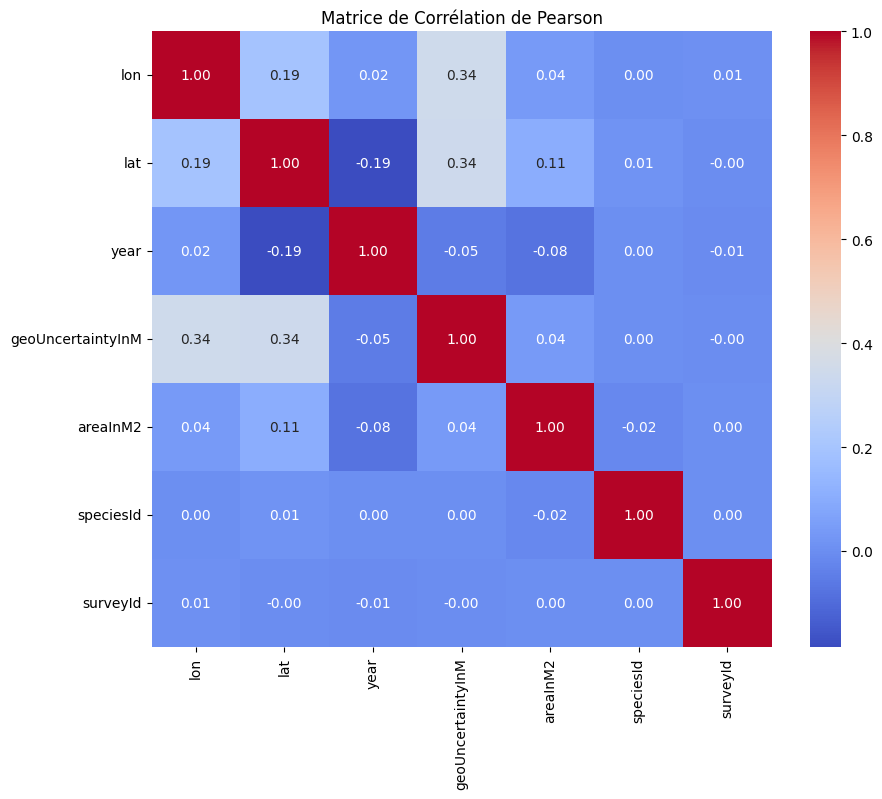

In [25]:
# 1. Sélectionner uniquement les colonnes numériques
# 2. Remplacer les infinis par NaN pour ne pas fausser le calcul
numeric_df = df_train.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)

# Calcul de la matrice de corrélation
corr_matrix = numeric_df.corr()

# Affichage avec une Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation de Pearson")
plt.show()

In [26]:
# Calcul de la matrice de covariance
cov_matrix = numeric_df.cov()
print(cov_matrix)

                            lon          lat         year  geoUncertaintyInM  \
lon                   19.689160     4.163661     0.117521           9.365322   
lat                    4.163661    23.552699    -0.985664          10.189230   
year                   0.117521    -0.985664     1.197985          -0.368076   
geoUncertaintyInM      9.365322    10.189230    -0.368076          38.326268   
areaInM2              32.823270   101.863703   -18.120888          53.293484   
speciesId             45.303780   245.448328    13.466428          41.886868   
surveyId           30816.025911 -2493.953493 -8291.303965       -3786.838753   

                        areaInM2     speciesId      surveyId  
lon                    32.823270  4.530378e+01  3.081603e+04  
lat                   101.863703  2.454483e+02 -2.493953e+03  
year                  -18.120888  1.346643e+01 -8.291304e+03  
geoUncertaintyInM      53.293484  4.188687e+01 -3.786839e+03  
areaInM2            46043.755270 -1.307667e+

## Filtrage des espèces rares

In [27]:
# Filtrer les espèces qui apparaissent au moins 10 fois
species_counts = df_train['speciesId'].value_counts()
common_species = species_counts[species_counts >= 80].index

# CORRECTION: utiliser .copy() pour éviter les SettingWithCopyWarning
df_train_filtered = df_train[df_train['speciesId'].isin(common_species)].copy()

print(f"Nombre d'espèces après filtrage : {df_train_filtered['speciesId'].nunique()}")

Nombre d'espèces après filtrage : 1271


In [28]:
before = len(df_train_filtered)
df_train_filtered = df_train_filtered.drop_duplicates()
after = len(df_train_filtered)
print(f"Lignes supprimées : {before - after}")
print(len(df_train_filtered))

Lignes supprimées : 19746
1404288


In [29]:
max_per_species = 1500

df_train_limited = (
    df_train_filtered
    .groupby('speciesId', group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), max_per_species), random_state=42))
)

print(df_train_limited['speciesId'].value_counts())
print(f"Lignes finales : {len(df_train_limited)}")

speciesId
53.0      1500
96.0      1500
146.0     1500
6950.0    1500
6962.0    1500
          ... 
4650.0      78
1824.0      78
2078.0      78
8307.0      76
2772.0      67
Name: count, Length: 1271, dtype: int64
Lignes finales : 694796


/tmp/ipykernel_2196499/1787966599.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_filtered


# Feature Engineering

In [30]:
def features_engineering(df):
    df = df.copy()
    
    # 1. Transformation Trigonométrique (Espace 3D)
    # Permet de représenter lat/lon sur une sphère, évite les discontinuités
    df['x'] = np.cos(np.radians(df['lat'])) * np.cos(np.radians(df['lon']))
    df['y'] = np.cos(np.radians(df['lat'])) * np.sin(np.radians(df['lon']))
    df['z'] = np.sin(np.radians(df['lat']))

    # 2. Interaction Pays-Région
    df['geo_zone'] = df['country'].astype(str) + "_" + df['region'].astype(str)

    # 3. Précision du relevé
    df['is_precise'] = (df['geoUncertaintyInM'] < 10).astype(int)
    
    return df

In [31]:
df_train_eng = features_engineering(df_train_limited)
print(df_train_eng.head())

             lon        lat  year  geoUncertaintyInM  areaInM2         region  \
134079  8.141420  56.296710  2017               10.0      79.0       ATLANTIC   
42318   8.206340  55.740290  2018               10.0      79.0       ATLANTIC   
590146  8.644410  57.071080  2017               10.0      79.0       ATLANTIC   
692435  3.500995  44.036364  2019               10.0      10.0  MEDITERRANEAN   
661277  6.371222  52.548254  2017                3.0       4.0       ATLANTIC   

            country  speciesId  surveyId         x         y         z  \
134079      Denmark        9.0    359272  0.549300  0.078582  0.831922   
42318       Denmark        9.0    117835  0.557181  0.080354  0.826494   
590146      Denmark        9.0   1570254  0.537423  0.081704  0.839346   
692435       France        9.0   1843894  0.717557  0.043900  0.695115   
661277  Netherlands        9.0   1764241  0.604337  0.067480  0.793866   

                    geo_zone  is_precise  
134079      Denmark_ATLAN

In [32]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

#Convertir lat/lon en indices de grille
def lat_lon_to_grid(lat, lon, grid_km=100):
    deg_per_km_lat = 1 / 111
    deg_per_km_lon = lambda lat: 1 / (111 * np.cos(np.radians(lat)))
    lat_idx = (lat / (deg_per_km_lat * grid_km)).astype(int)
    lon_idx = (lon / (deg_per_km_lon(lat) * grid_km)).astype(int)
    return lat_idx, lon_idx

df_train_eng['lat_grid'], df_train_eng['lon_grid'] = lat_lon_to_grid(df_train_eng['lat'], df_train_eng['lon'], grid_km=100)
df_train_eng['zone_grid'] = df_train_eng['lat_grid'].astype(str) + "_" + df_train_eng['lon_grid'].astype(str)

# Créer un Geo-bloc pour chaque zone (DBSCAN sur les indices)
zone_coords = df_train_eng[['lat_grid', 'lon_grid']].drop_duplicates()
coords_array = zone_coords.values

# DBSCAN pour détecter les zones contiguës
db = DBSCAN(eps=1.5, min_samples=1, metric='chebyshev')  # Chebyshev = voisinage sur la grille
zone_coords['block'] = db.fit_predict(coords_array)

# Split train/test par bloc (pas de zones adjacentes dans le test)
blocks = zone_coords['block'].unique()
np.random.seed(42)
test_blocks = np.random.choice(blocks, size=int(0.35 * len(blocks)), replace=False)
train_blocks = [b for b in blocks if b not in test_blocks]

# Créer les ensembles train/test
train_zones = zone_coords[zone_coords['block'].isin(train_blocks)].apply(
    lambda row: f"{row['lat_grid']}_{row['lon_grid']}", axis=1
)
test_zones = zone_coords[zone_coords['block'].isin(test_blocks)].apply(
    lambda row: f"{row['lat_grid']}_{row['lon_grid']}", axis=1
)

df_train_split = df_train_eng[df_train_eng['zone_grid'].isin(train_zones)].copy()
df_test_split  = df_train_eng[df_train_eng['zone_grid'].isin(test_zones)].copy()

print(f"Lignes Train : {len(df_train_split)}, Lignes Test : {len(df_test_split)}")
print(f"Espèces uniques Train : {df_train_split['speciesId'].nunique()}, Test : {df_test_split['speciesId'].nunique()}")

Lignes Train : 690312, Lignes Test : 4484
Espèces uniques Train : 1271, Test : 261


In [33]:
import multiprocessing
import psutil
from xgboost import XGBClassifier

# 25% des cœurs disponibles
n_cores = max(1, int(multiprocessing.cpu_count() * 0.25))
print(f"Utilisation de {n_cores} cœurs CPU")

# 25% de la RAM disponible
mem = psutil.virtual_memory()
max_memory_MB = int(mem.available / 1024 / 1024 * 0.25)
print(f"Limitation de la mémoire à {max_memory_MB} MB")


Utilisation de 8 cœurs CPU
Limitation de la mémoire à 56480 MB


In [34]:
from sklearn.preprocessing import LabelEncoder

# Target : encoder les species
le_species = LabelEncoder()
y_train = le_species.fit_transform(df_train_split['speciesId'])

In [35]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = ['geo_zone']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit sur train
df_train_split[categorical_cols] = encoder.fit_transform(df_train_split[categorical_cols])

# Transform sur test (les zones inconnues seront encodées -1)
df_test_split[categorical_cols] = encoder.transform(df_test_split[categorical_cols])

# Ajouter à la liste des features
features = ['x', 'y', 'z', 'is_precise'] + categorical_cols

In [36]:
# Features et target
X_train = df_train_split[features]
X_test  = df_test_split[features]
y_train = le_species.fit_transform(df_train_split['speciesId'])

In [37]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le_species.classes_),
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',      # moins gourmand en RAM
    max_bin=256,             # réduire pour moins de mémoire
    random_state=42,
    n_jobs=n_cores           # limite le nombre de cœurs CPU
)

In [38]:
model.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
# Seuil pour considérer qu'une espèce est présente
threshold = 0.05
proba = model.predict_proba(X_test)

# Construire les prédictions multi-label
pred_list = []
for row in proba:
    indices = np.where(row > threshold)[0]
    species = le_species.inverse_transform(indices)
    pred_list.append(" ".join(map(str, species)))

In [ ]:
submission = pd.DataFrame({
    'surveyId': df_test_split['surveyId'].values,
    'predictions': pred_list
})

submission.to_csv('submission.csv', index=False)
print(submission.head())